# Análisis de Datos de Llamadas — Yarvis Challenge

> Dataset: ~73,000 registros de llamadas salientes de un agente de voz IA.  
> Pipeline: CSV → Limpieza → Sentimiento → Contactabilidad → Clustering → Desempeño del Agente

In [66]:
import os, sys
from pathlib import Path

os.environ.setdefault("PYTHONIOENCODING", "utf-8")
sys.path.insert(0, str(Path.cwd() / "scripts"))
sys.path.insert(0, str(Path.cwd() / "utils"))

import numpy as np
import polars as pl
from IPython.display import Image, display

PROCESSED = Path.cwd() / "data" / "processed"
FIGURES   = Path.cwd() / "reports" / "figures"

In [ ]:
# Ejecutar pipeline completo (silencioso)
from load_data import load_raw
from clean_data import clean
from sentiment_analysis import analyze_sentiment
from contactability import analyze_contactability
from cluster_contacts import cluster_contacts
from agent_performance import analyze_agent_performance

df = load_raw()
df = clean(df)
df = analyze_sentiment(df)
df = analyze_contactability(df)
df = cluster_contacts(df)
df = analyze_agent_performance(df)

print(f"Pipeline completado: {df.height:,} registros, {df.width} columnas")

[INFO] Registros cargados: 73,487
[INFO] Registros inconsistentes (connected != call_completed): 16,700
[INFO] Outliers de duracion (>p99): 304
[INFO] Distribucion pca_sentimiento:
shape: (4, 2)
┌─────────────────┬───────┐
│ pca_sentimiento ┆ count │
│ ---             ┆ ---   │
│ str             ┆ u32   │
╞═════════════════╪═══════╡
│ null            ┆ 71274 │
│ neutral         ┆ 2034  │
│ positivo        ┆ 109   │
│ negativo        ┆ 70    │
└─────────────────┴───────┘
[INFO] Exportado: calls_clean.csv (73,487 filas, 26 columnas)
[INFO] Cache encontrado: cache_sentiment.csv (73,487 filas)
[INFO] Cache encontrado: figuras de contactabilidad ya existen
Pipeline completado: 73,487 registros, 28 columnas


In [68]:
# DataFrames auxiliares reutilizados en las secciones
df_connected = df.filter(pl.col("connected") == True)
df_clusters  = pl.read_csv(PROCESSED / "clusters_contacts.csv")

print(f"Total de llamadas:     {df.height:,}")
print(f"Llamadas conectadas:   {df_connected.height:,} ({df_connected.height/df.height:.1%})")
print(f"Llamadas no conectadas: {df.height - df_connected.height:,}")

Total de llamadas:     73,487
Llamadas conectadas:   13,751 (18.7%)
Llamadas no conectadas: 59,736


---
# Visualización previa

In [69]:
col = ['campaign_id',
 'target_id',
 'connected',
 'disconnected_reason',
 'duration_ms',
 'transcript',
 'post_call_analysis',
 'executed_at',
 'call_completed',
 'hour',
 'day_of_month',
 'date',
 'day_of_week',
 'duration_sec',
 'duration_outlier',
 'pca_resumen',
 'pca_sentimiento',
 'sentiment_own',
 'campaign_type']
df.filter(pl.col("campaign_type") == "prueba").select(col)

campaign_id,target_id,connected,disconnected_reason,duration_ms,transcript,post_call_analysis,executed_at,call_completed,hour,day_of_month,date,day_of_week,duration_sec,duration_outlier,pca_resumen,pca_sentimiento,sentiment_own,campaign_type
str,i64,bool,str,f64,str,str,datetime[μs],bool,i8,i8,str,str,f64,bool,str,str,str,str
"""6688""",430429,false,"""system_error""",null,null,null,2026-01-21 20:47:02.363,false,20,21,"""21/01/2026""","""ju""",null,false,null,null,"""neutral""","""prueba"""
"""6688""",430425,false,"""system_error""",null,null,null,2026-01-21 20:37:04.293,false,20,21,"""21/01/2026""","""ju""",null,false,null,null,"""neutral""","""prueba"""
"""6688""",430430,true,"""user_hangup""",5389.0,"""[""Agent: Hola David, ¿cómo vas…","""{""mudanza"": false, ""razon_chur…",2026-01-21 20:16:20.008,true,20,21,"""21/01/2026""","""ju""",5.389,false,null,"""neutral""","""neutral""","""prueba"""
"""6688""",430426,true,"""user_hangup""",34214.0,"""[""Agent: Hola, ¿cómo vas? Te h…","""{""mudanza"": false, ""razon_chur…",2026-01-21 20:08:34.865,true,20,21,"""21/01/2026""","""ju""",34.214,false,null,"""neutral""","""neutral""","""prueba"""


---
# 0. Patrones de Contactabilidad

> *Identifica cuándo los contactos son más alcanzables.*

<details open>
<summary><h3>0.1 ¿Qué horas del día producen las tasas de conexión más altas?</h3></summary>

Se calculó la **tasa de conexión** (llamadas conectadas / total) para cada hora del día (0–23h).
</details>

shape: (13, 4)
┌──────┬───────┬────────────┬──────────┐
│ hour ┆ total ┆ conectadas ┆ tasa     │
│ ---  ┆ ---   ┆ ---        ┆ ---      │
│ i8   ┆ u32   ┆ i32        ┆ f64      │
╞══════╪═══════╪════════════╪══════════╡
│ 0    ┆ 153   ┆ 35         ┆ 0.228758 │
│ 10   ┆ 20    ┆ 2          ┆ 0.1      │
│ 13   ┆ 1148  ┆ 221        ┆ 0.192509 │
│ 14   ┆ 2520  ┆ 406        ┆ 0.161111 │
│ 15   ┆ 7399  ┆ 1347       ┆ 0.182052 │
│ …    ┆ …     ┆ …          ┆ …        │
│ 19   ┆ 7421  ┆ 1453       ┆ 0.195796 │
│ 20   ┆ 5538  ┆ 1149       ┆ 0.207476 │
│ 21   ┆ 7540  ┆ 1332       ┆ 0.176658 │
│ 22   ┆ 7608  ┆ 1272       ┆ 0.167192 │
│ 23   ┆ 4482  ┆ 677        ┆ 0.151049 │
└──────┴───────┴────────────┴──────────┘


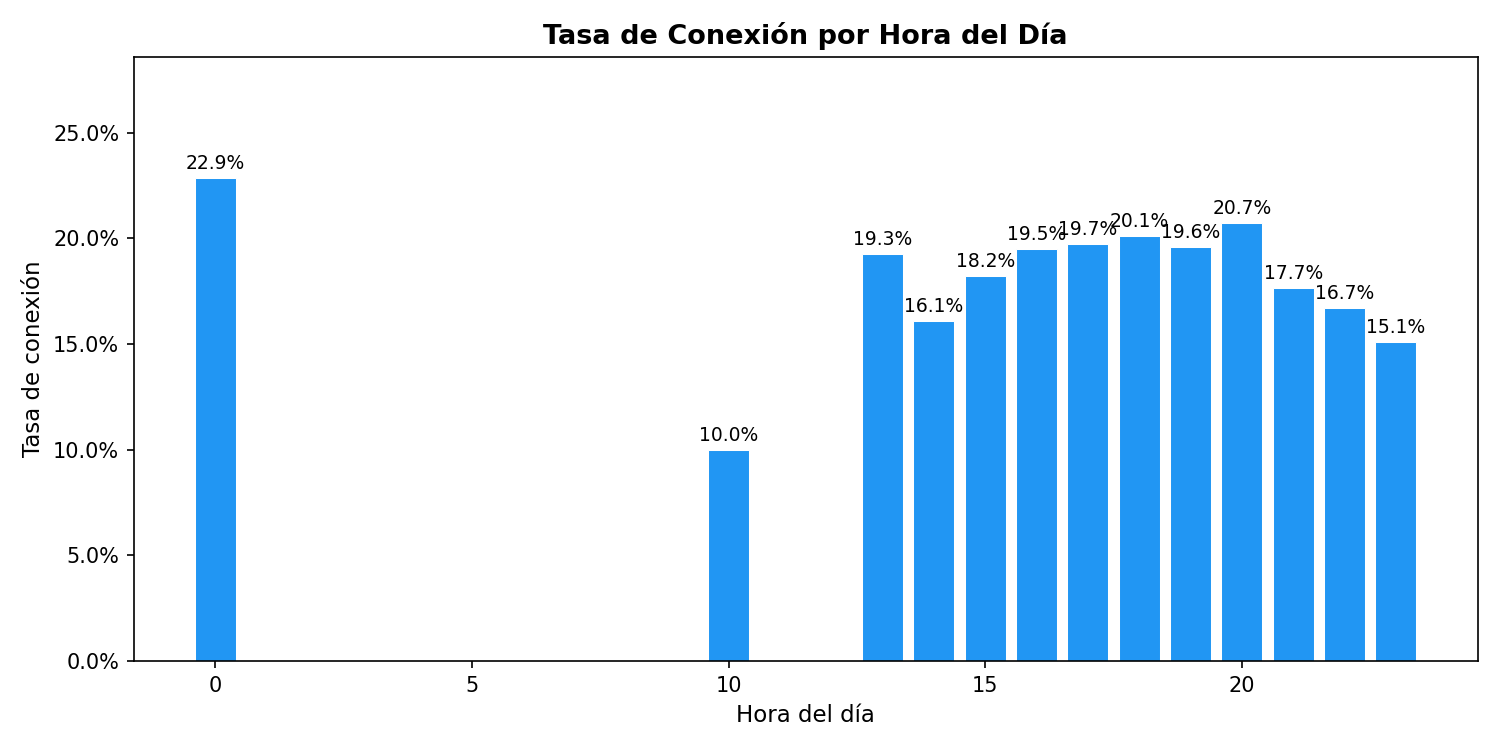

In [70]:
# Tasa de conexión por hora
by_hour = (
    df.group_by("hour")
    .agg([
        pl.len().alias("total"),
        pl.col("connected").cast(pl.Int32).sum().alias("conectadas"),
    ])
    .with_columns((pl.col("conectadas") / pl.col("total")).alias("tasa"))
    .sort("hour")
)
print(by_hour.select(["hour", "total", "conectadas", "tasa"]))

display(Image(FIGURES / "contactability_by_hour.png"))

<details open>
<summary><h3>0.2 ¿Hay diferencias por día de la semana?</h3></summary>

Tasa de conexión agrupada por día de la semana (lu–do).
</details>

shape: (6, 4)
┌─────────────┬───────┬────────────┬──────────┐
│ day_of_week ┆ total ┆ conectadas ┆ tasa     │
│ ---         ┆ ---   ┆ ---        ┆ ---      │
│ str         ┆ u32   ┆ i32        ┆ f64      │
╞═════════════╪═══════╪════════════╪══════════╡
│ ma          ┆ 16847 ┆ 2779       ┆ 0.164955 │
│ mi          ┆ 22953 ┆ 4143       ┆ 0.180499 │
│ ju          ┆ 17700 ┆ 3917       ┆ 0.221299 │
│ vi          ┆ 3496  ┆ 572        ┆ 0.163616 │
│ sa          ┆ 5817  ┆ 1135       ┆ 0.195118 │
│ do          ┆ 6674  ┆ 1205       ┆ 0.180551 │
└─────────────┴───────┴────────────┴──────────┘


C:\Users\andre\AppData\Local\Temp\ipykernel_16072\783613938.py:11: DeprecationWarning: the `default` parameter for `replace` is deprecated. Use `replace_strict` instead to set a default while replacing values.
(Deprecated in version 1.0.0)
  pl.col("day_of_week").replace(DOW_ORDER, list(range(7)), default=99).cast(pl.Int8).alias("_rank"),


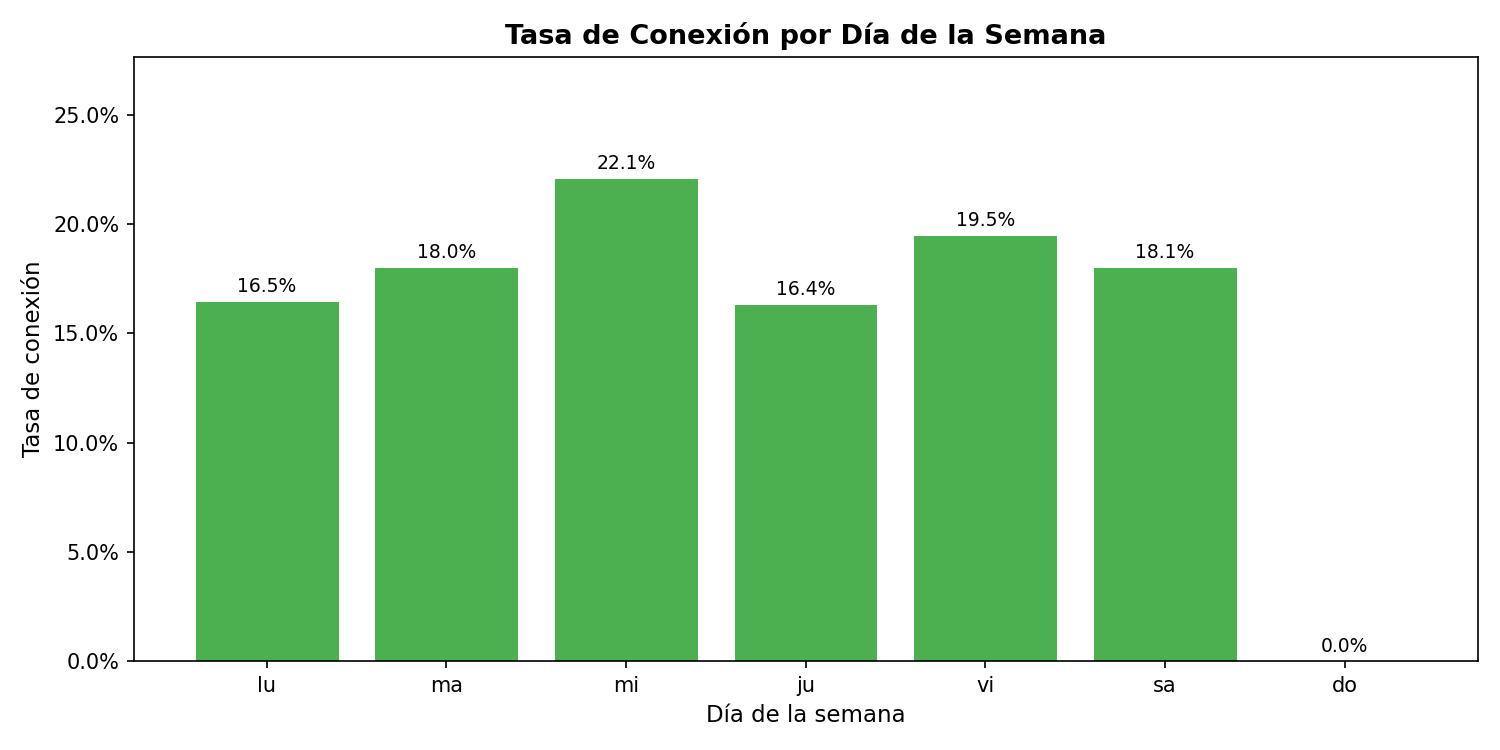

In [71]:
# Tasa de conexión por día de la semana
DOW_ORDER = ["lu", "ma", "mi", "ju", "vi", "sa", "do"]
by_dow = (
    df.group_by("day_of_week")
    .agg([
        pl.len().alias("total"),
        pl.col("connected").cast(pl.Int32).sum().alias("conectadas"),
    ])
    .with_columns([
        (pl.col("conectadas") / pl.col("total")).alias("tasa"),
        pl.col("day_of_week").replace(DOW_ORDER, list(range(7)), default=99).cast(pl.Int8).alias("_rank"),
    ])
    .sort("_rank")
    .drop("_rank")
)
print(by_dow.select(["day_of_week", "total", "conectadas", "tasa"]))

display(Image(FIGURES / "contactability_by_dow.png"))

<details open>
<summary><h3>0.3 ¿Hay diferencias por tipo de campaña?</h3></summary>

El campo `name` se clasificó por regex en tipos de campaña: churn_prevention, upsell, cobranza, sales, etc.
</details>

shape: (9, 4)
┌──────────────────┬───────┬────────────┬──────────┐
│ campaign_type    ┆ total ┆ conectadas ┆ tasa     │
│ ---              ┆ ---   ┆ ---        ┆ ---      │
│ str              ┆ u32   ┆ i32        ┆ f64      │
╞══════════════════╪═══════╪════════════╪══════════╡
│ prueba           ┆ 4     ┆ 2          ┆ 0.5      │
│ sales            ┆ 4     ┆ 1          ┆ 0.25     │
│ upsell           ┆ 14448 ┆ 2983       ┆ 0.206465 │
│ cobranza         ┆ 2602  ┆ 525        ┆ 0.201768 │
│ servicio_cliente ┆ 1884  ┆ 377        ┆ 0.200106 │
│ promo            ┆ 502   ┆ 95         ┆ 0.189243 │
│ churn_prevention ┆ 42307 ┆ 7675       ┆ 0.181412 │
│ otro             ┆ 6315  ┆ 1140       ┆ 0.180523 │
│ aviso            ┆ 5421  ┆ 953        ┆ 0.175798 │
└──────────────────┴───────┴────────────┴──────────┘


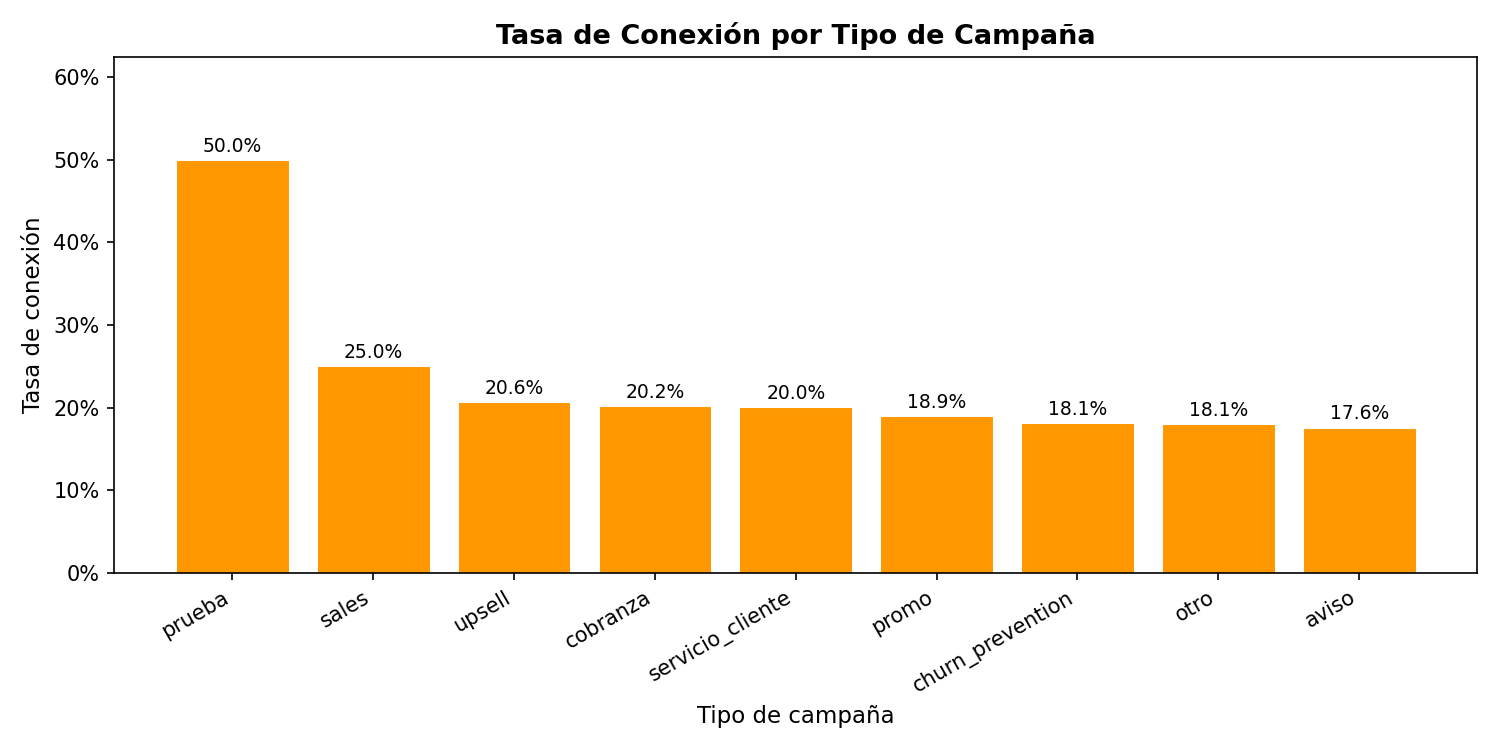

In [72]:
# Tasa de conexión por tipo de campaña
by_camp = (
    df.group_by("campaign_type")
    .agg([
        pl.len().alias("total"),
        pl.col("connected").cast(pl.Int32).sum().alias("conectadas"),
    ])
    .with_columns((pl.col("conectadas") / pl.col("total")).alias("tasa"))
    .sort("tasa", descending=True)
)
print(by_camp.select(["campaign_type", "total", "conectadas", "tasa"]))

display(Image(FIGURES / "contactability_by_campaign.png"))

<details open>
<summary><h3>0.4 ¿Cuál es la ventana óptima de llamadas para maximizar conexiones exitosas?</h3></summary>

Heatmap de hora × día de la semana. Los combos con al menos 10 llamadas se rankean por tasa de conexión.
</details>

Top 10 ventanas óptimas (día + hora):
shape: (10, 4)
┌─────────────┬──────┬───────┬──────────┐
│ day_of_week ┆ hour ┆ total ┆ tasa     │
│ ---         ┆ ---  ┆ ---   ┆ ---      │
│ str         ┆ i8   ┆ u32   ┆ f64      │
╞═════════════╪══════╪═══════╪══════════╡
│ sa          ┆ 17   ┆ 567   ┆ 0.324515 │
│ ju          ┆ 19   ┆ 2079  ┆ 0.286195 │
│ ju          ┆ 20   ┆ 2361  ┆ 0.278695 │
│ sa          ┆ 18   ┆ 475   ┆ 0.275789 │
│ sa          ┆ 16   ┆ 560   ┆ 0.267857 │
│ ju          ┆ 0    ┆ 37    ┆ 0.243243 │
│ ju          ┆ 18   ┆ 2241  ┆ 0.238286 │
│ vi          ┆ 16   ┆ 239   ┆ 0.23431  │
│ mi          ┆ 0    ┆ 109   ┆ 0.220183 │
│ do          ┆ 16   ┆ 1988  ┆ 0.210262 │
└─────────────┴──────┴───────┴──────────┘


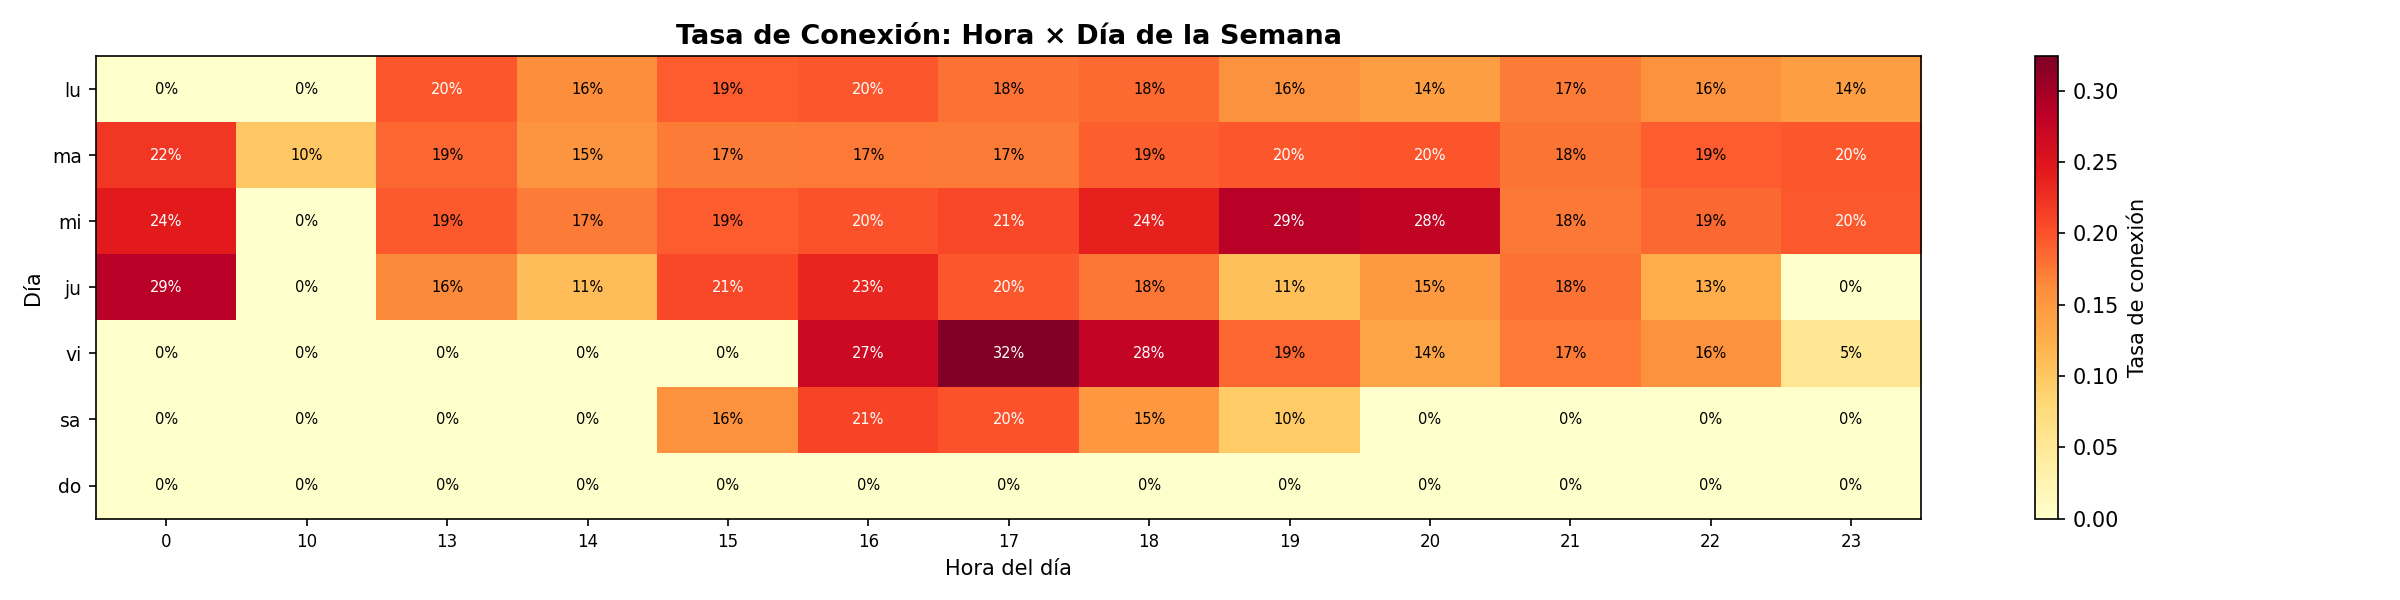

In [73]:
# Top 10 ventanas hora × día con mayor tasa de conexión (min 10 llamadas)
top_windows = (
    df.with_columns(pl.col("connected").cast(pl.Int32))
    .group_by(["day_of_week", "hour"])
    .agg([
        pl.len().alias("total"),
        pl.col("connected").sum().alias("conectadas"),
    ])
    .with_columns((pl.col("conectadas") / pl.col("total")).alias("tasa"))
    .filter(pl.col("total") >= 10)
    .sort("tasa", descending=True)
    .head(10)
)
print("Top 10 ventanas óptimas (día + hora):")
print(top_windows.select(["day_of_week", "hour", "total", "tasa"]))

display(Image(FIGURES / "contactability_heatmap.png"))

---
# 1. Clusters de Contactos

> *De las llamadas conectadas, identifica clusters distintos de contactos.*

<details open>
<summary><h3>1.1 ¿Qué clusters emergen de los datos?</h3></summary>

**Algoritmo**: K-Prototypes (maneja datos numéricos + categóricos nativamente, sin necesidad de one-hot encoding).  
**Features numéricas**: `duration_sec`, `transcript_length`, `hour` (escaladas con StandardScaler).  
**Features categóricas**: `disconnected_reason`, `sentiment_own` (usadas directamente como strings).  
**Selección de K**: Calinski-Harabasz Index (mayor = mejor separación), evaluando k ∈ [2, 8].  
**Reproducibilidad**: `random_state=42`, inicialización Cao.
</details>

Distribución de Clusters (K-Prototypes, k=3):

shape: (3, 3)
┌────────────┬──────┬──────┐
│ cluster_id ┆ n    ┆ pct  │
│ ---        ┆ ---  ┆ ---  │
│ i64        ┆ u32  ┆ f64  │
╞════════════╪══════╪══════╡
│ 0          ┆ 6961 ┆ 50.6 │
│ 1          ┆ 5022 ┆ 36.5 │
│ 2          ┆ 1768 ┆ 12.9 │
└────────────┴──────┴──────┘


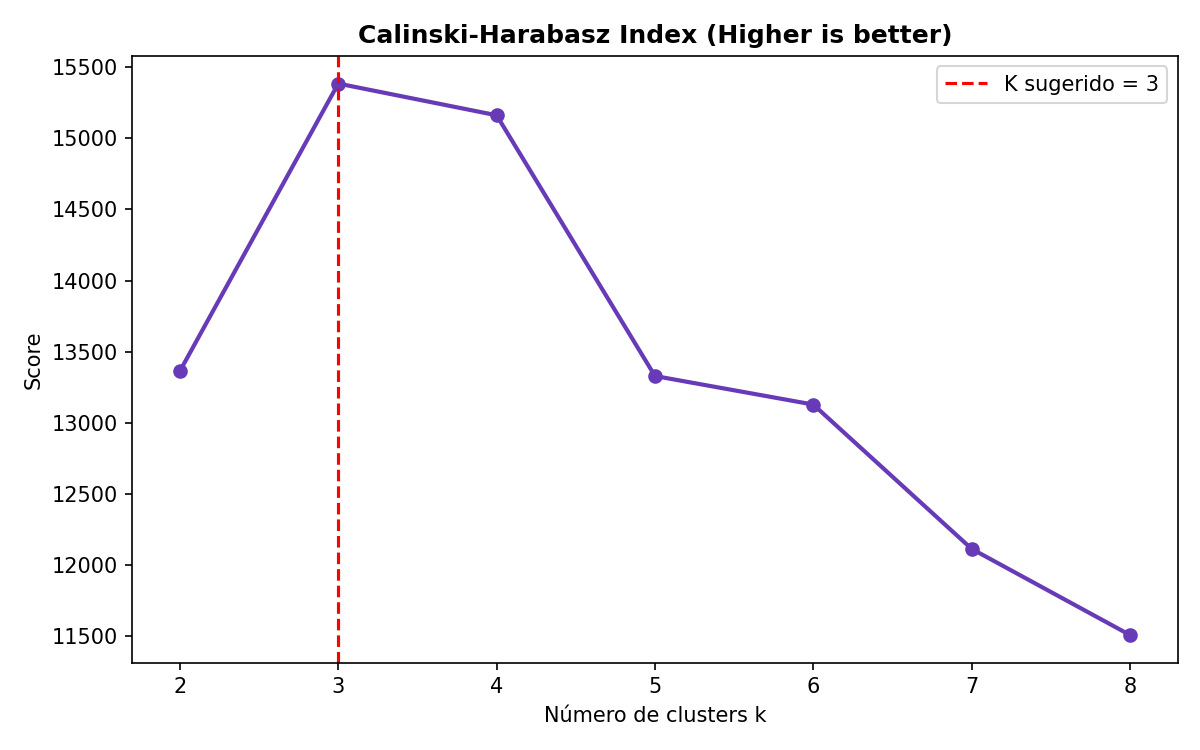

In [74]:
# Distribución de clusters
dist = (
    df_clusters.group_by("cluster_id")
    .agg(pl.len().alias("n"))
    .sort("cluster_id")
    .with_columns((pl.col("n") / pl.col("n").sum() * 100).round(1).alias("pct"))
)
print("Distribución de Clusters (K-Prototypes, k=3):\n")
print(dist)

display(Image(FIGURES / "cluster_evaluation.png"))

<details open>
<summary><h3>1.2 ¿Cuáles son las características y tendencias comunes dentro de cada cluster?</h3></summary>

Perfil de cada cluster: métricas numéricas + distribución de variables categóricas.
</details>

Perfil numérico por cluster:

shape: (3, 6)
┌────────────┬────────────┬──────────────┬────────────┬───────────┬──────┐
│ cluster_id ┆ dur_mean_s ┆ dur_median_s ┆ trans_mean ┆ hour_mean ┆ n    │
│ ---        ┆ ---        ┆ ---          ┆ ---        ┆ ---       ┆ ---  │
│ i64        ┆ f64        ┆ f64          ┆ f64        ┆ f64       ┆ u32  │
╞════════════╪════════════╪══════════════╪════════════╪═══════════╪══════╡
│ 0          ┆ 29.1       ┆ 15.8         ┆ 324.0      ┆ 16.2      ┆ 6961 │
│ 1          ┆ 28.7       ┆ 14.9         ┆ 321.0      ┆ 20.8      ┆ 5022 │
│ 2          ┆ 290.0      ┆ 260.0        ┆ 4226.0     ┆ 18.4      ┆ 1768 │
└────────────┴────────────┴──────────────┴────────────┴───────────┴──────┘


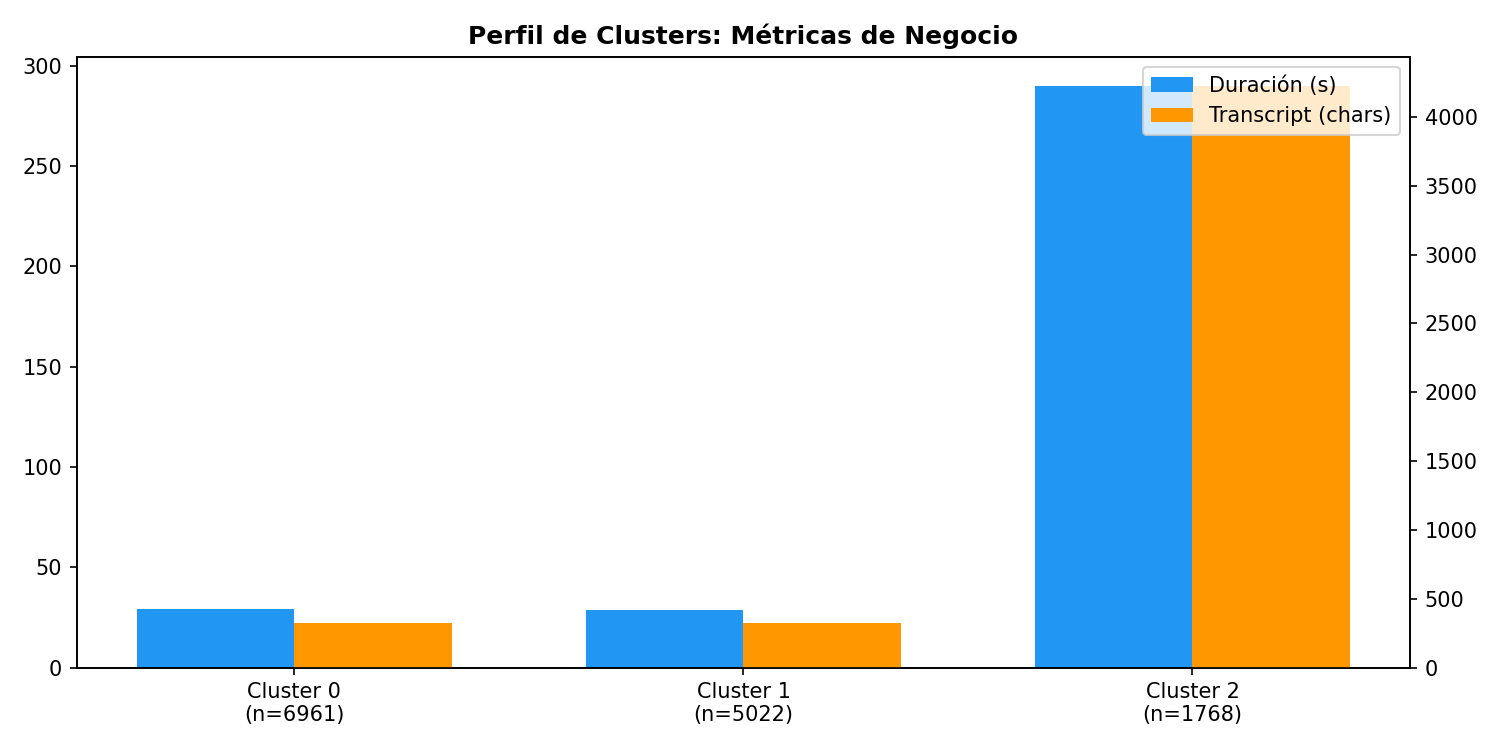

In [75]:
# Perfil numérico por cluster
profile = (
    df_clusters.group_by("cluster_id")
    .agg([
        pl.col("duration_sec").mean().round(1).alias("dur_mean_s"),
        pl.col("duration_sec").median().round(1).alias("dur_median_s"),
        pl.col("transcript_length").mean().round(0).alias("trans_mean"),
        pl.col("hour").mean().round(1).alias("hour_mean"),
        pl.len().alias("n"),
    ])
    .sort("cluster_id")
)
print("Perfil numérico por cluster:\n")
print(profile)

display(Image(FIGURES / "cluster_profiles.png"))

In [76]:
# Perfil categórico: razón de desconexión por cluster
print("Razón de desconexión por cluster:\n")
for cid in sorted(df_clusters["cluster_id"].unique().to_list()):
    sub = df_clusters.filter(pl.col("cluster_id") == cid)
    reason_dist = (
        sub.group_by("disconnected_reason")
        .agg(pl.len().alias("n"))
        .with_columns((pl.col("n") / sub.height * 100).round(1).alias("pct"))
        .sort("n", descending=True)
    )
    print(f"--- Cluster {cid} ({sub.height:,} registros) ---")
    print(reason_dist)
    print()

# Sentimiento por cluster
print("Sentimiento propio por cluster:\n")
for cid in sorted(df_clusters["cluster_id"].unique().to_list()):
    sub = df_clusters.filter(pl.col("cluster_id") == cid)
    sent_dist = (
        sub.group_by("sentiment_own")
        .agg(pl.len().alias("n"))
        .with_columns((pl.col("n") / sub.height * 100).round(1).alias("pct"))
        .sort("n", descending=True)
    )
    print(f"--- Cluster {cid} ---")
    print(sent_dist)
    print()

Razón de desconexión por cluster:

--- Cluster 0 (6,961 registros) ---
shape: (4, 3)
┌─────────────────────┬──────┬──────┐
│ disconnected_reason ┆ n    ┆ pct  │
│ ---                 ┆ ---  ┆ ---  │
│ str                 ┆ u32  ┆ f64  │
╞═════════════════════╪══════╪══════╡
│ user_hangup         ┆ 4756 ┆ 68.3 │
│ inactivity          ┆ 1879 ┆ 27.0 │
│ agent_hangup        ┆ 325  ┆ 4.7  │
│ ivr_reached         ┆ 1    ┆ 0.0  │
└─────────────────────┴──────┴──────┘

--- Cluster 1 (5,022 registros) ---
shape: (4, 3)
┌─────────────────────┬──────┬──────┐
│ disconnected_reason ┆ n    ┆ pct  │
│ ---                 ┆ ---  ┆ ---  │
│ str                 ┆ u32  ┆ f64  │
╞═════════════════════╪══════╪══════╡
│ user_hangup         ┆ 3714 ┆ 74.0 │
│ inactivity          ┆ 1084 ┆ 21.6 │
│ agent_hangup        ┆ 215  ┆ 4.3  │
│ ivr_reached         ┆ 9    ┆ 0.2  │
└─────────────────────┴──────┴──────┘

--- Cluster 2 (1,768 registros) ---
shape: (4, 3)
┌──────────────────────┬──────┬──────┐
│ disconnected

<details open>
<summary><h3>1.3 ¿Por qué están agrupados juntos? ¿Qué diferencia a cada cluster?</h3></summary>

**Hallazgo clave**: La correlación entre `duration_sec` y `transcript_length` es **0.992** (casi perfecta). Esto implica que ambas variables son esencialmente redundantes — el algoritmo separa por **duración de la llamada** como eje dominante.

La diferencia real entre Cluster 0 y 1 reside en las **variables categóricas** (razón de desconexión y sentimiento), no en las numéricas.
</details>

In [77]:
# Verificación: correlación duration_sec ↔ transcript_length
dur = df_clusters["duration_sec"].to_numpy()
tl  = df_clusters["transcript_length"].to_numpy()
mask = ~(np.isnan(dur) | np.isnan(tl))
corr_global = np.corrcoef(dur[mask], tl[mask])[0, 1]

print(f"Correlación global duration_sec vs transcript_length: {corr_global:.3f}")
print()

for cid in sorted(df_clusters["cluster_id"].unique().to_list()):
    sub = df_clusters.filter(pl.col("cluster_id") == cid)
    d = sub["duration_sec"].to_numpy()
    t = sub["transcript_length"].to_numpy()
    m = ~(np.isnan(d) | np.isnan(t))
    c = np.corrcoef(d[m], t[m])[0, 1]
    print(f"  Cluster {cid}: corr = {c:.3f}")

Correlación global duration_sec vs transcript_length: 0.992

  Cluster 0: corr = 0.955
  Cluster 1: corr = 0.956
  Cluster 2: corr = 0.976


---
# 2. Análisis de Sentimiento

> *Clasifica los contactos en sentimiento Negativo, Neutral y Positivo. Ve más allá de los campos existentes de Post Call Analysis — deriva tu propia clasificación de sentimiento y justifícala.*

<details open>
<summary><h3>2.1 Metodología propia de clasificación de sentimiento</h3></summary>

Se implementó un **clasificador léxico en español** (`scripts/sentiment_analysis.py`) que:

1. **Extrae solo el texto del usuario** del transcript (ignora líneas del Agent)
2. Evalúa **frases completas** con peso doble (ej. "no me interesa" = -2, "si me interesa" = +2)
3. Evalúa **palabras individuales** contra un léxico de ~70 términos positivos y ~70 negativos
4. Clasifica: score ≥ 1 → positivo, score ≤ -1 → negativo, resto → neutral
5. Llamadas sin texto de usuario → neutral (no hay señal para clasificar)

**Justificación**: Un enfoque léxico es transparente, auditable, y no requiere modelos pesados. Es apropiado dado que el contexto es acotado (atención al cliente de telecomunicaciones en español).
</details>

<details open>
<summary><h3>2.2 ¿Cuál es la distribución de sentimiento a través de las llamadas?</h3></summary>
</details>

In [78]:
# Distribución de sentiment_own (clasificación propia)
sent_dist = (
    df.group_by("sentiment_own")
    .agg(pl.len().alias("n"))
    .with_columns((pl.col("n") / df.height * 100).round(1).alias("pct"))
    .sort("n", descending=True)
)
print("Distribución de sentimiento propio (todas las llamadas):\n")
print(sent_dist)

# Solo conectadas
sent_conn = (
    df_connected.group_by("sentiment_own")
    .agg(pl.len().alias("n"))
    .with_columns((pl.col("n") / df_connected.height * 100).round(1).alias("pct"))
    .sort("n", descending=True)
)
print("\nDistribución de sentimiento (solo conectadas):\n")
print(sent_conn)

# Comparación con pca_sentimiento (campo del PCA original)
overlap = df.filter(pl.col("pca_sentimiento").is_not_null())
if overlap.height > 0:
    match = overlap.filter(pl.col("sentiment_own") == pl.col("pca_sentimiento")).height
    print(f"\nConcordancia con pca_sentimiento (IA original): {match}/{overlap.height} = {match/overlap.height:.1%}")

Distribución de sentimiento propio (todas las llamadas):

shape: (3, 3)
┌───────────────┬───────┬──────┐
│ sentiment_own ┆ n     ┆ pct  │
│ ---           ┆ ---   ┆ ---  │
│ str           ┆ u32   ┆ f64  │
╞═══════════════╪═══════╪══════╡
│ neutral       ┆ 70061 ┆ 95.3 │
│ positivo      ┆ 3267  ┆ 4.4  │
│ negativo      ┆ 159   ┆ 0.2  │
└───────────────┴───────┴──────┘

Distribución de sentimiento (solo conectadas):

shape: (3, 3)
┌───────────────┬───────┬──────┐
│ sentiment_own ┆ n     ┆ pct  │
│ ---           ┆ ---   ┆ ---  │
│ str           ┆ u32   ┆ f64  │
╞═══════════════╪═══════╪══════╡
│ neutral       ┆ 10338 ┆ 75.2 │
│ positivo      ┆ 3259  ┆ 23.7 │
│ negativo      ┆ 154   ┆ 1.1  │
└───────────────┴───────┴──────┘

Concordancia con pca_sentimiento (IA original): 2009/2213 = 90.8%


<details open>
<summary><h3>2.3 ¿Qué impulsa cada categoría? Ejemplos concretos de transcripciones</h3></summary>
</details>

In [79]:
# Ejemplos representativos de cada sentimiento (solo texto del usuario, llamadas conectadas)
import re

def extract_user_text(transcript):
    if not transcript:
        return ""
    return " | ".join(
        line.strip()[5:].strip()
        for line in transcript.split("\n")
        if line.strip().startswith("User:")
    )

for sentiment in ["positivo", "negativo", "neutral"]:
    sample = (
        df_connected
        .filter(
            (pl.col("sentiment_own") == sentiment)
            & pl.col("transcript_text").is_not_null()
            & (pl.col("transcript_length") > 100)
        )
        .sample(n=min(3, df_connected.filter(
            (pl.col("sentiment_own") == sentiment)
            & pl.col("transcript_text").is_not_null()
            & (pl.col("transcript_length") > 100)
        ).height), seed=42)
    )
    print(f"\n{'='*70}")
    print(f"  SENTIMIENTO: {sentiment.upper()} ({sample.height} ejemplos)")
    print(f"{'='*70}")
    for i, row in enumerate(sample.iter_rows(named=True)):
        user_text = extract_user_text(row["transcript_text"])
        if len(user_text) > 300:
            user_text = user_text[:300] + "..."
        print(f"\n  [{i+1}] Duración: {row['duration_sec']:.0f}s | Razón: {row['disconnected_reason']}")
        print(f"      Usuario dijo: \"{user_text}\"")


  SENTIMIENTO: POSITIVO (3 ejemplos)

  [1] Duración: 284s | Razón: user_hangup
      Usuario dijo: "Aló. | Bien. | ¿De cuál? | ¿De a dónde | se llama? | Estoy ocupado todavía. | ¿Me | puedes llamar más luego? | Porque no, de verdad | que | Ella | ¿Cuál? | No entiendo nada todavía. | ¿Qué es lo | que tú me preguntas? | ¿De qué, de qué? | ¿De qué me preguntas tú? | Que no entiendo, madre. | No, a mí..."

  [2] Duración: 463s | Razón: user_hangup
      Usuario dijo: "Buenas noches. | El scooter. | No, lo que pasa es que estoy estoy estoy comiendo. La escucho, me escuché lo que me dijo le le escucho lo de la oferta. | Sí, | Precio por día, no precio de está hablando de televisión e internet. | Sí, sí me gustaría, la pregunta otra la otra pregunta sería ¿cómo se? ..."

  [3] Duración: 185s | Razón: agent_hangup
      Usuario dijo: "Muy bien, Muy buena señal. | No, no, muy bien, no molesta para nada. | Esa era la duda que tenía, porque no sabía, este, o sea, cómo saber si ya se estaba acab

<details open>
<summary><h3>2.4 ¿Hay patrones por tipo de campaña, hora del día, o duración?</h3></summary>
</details>

In [80]:
# Sentimiento por tipo de campaña
print("Sentimiento por tipo de campaña (solo conectadas):\n")
sent_by_camp = (
    df_connected.group_by(["campaign_type", "sentiment_own"])
    .agg(pl.len().alias("n"))
    .sort(["campaign_type", "sentiment_own"])
)
# Pivot para tabla cruzada
pivot = sent_by_camp.pivot(on="sentiment_own", index="campaign_type", values="n").fill_null(0)
print(pivot)

# Sentimiento por duración
print("\nDuración media por sentimiento (solo conectadas):\n")
dur_by_sent = (
    df_connected.group_by("sentiment_own")
    .agg([
        pl.col("duration_sec").mean().round(1).alias("dur_mean_s"),
        pl.col("duration_sec").median().round(1).alias("dur_median_s"),
        pl.col("transcript_length").mean().round(0).alias("trans_mean"),
        pl.len().alias("n"),
    ])
    .sort("n", descending=True)
)
print(dur_by_sent)

# Sentimiento por hora
print("\nDistribución de sentimiento negativo por hora (top 5 horas con más negativos):\n")
neg_by_hour = (
    df_connected.filter(pl.col("sentiment_own") == "negativo")
    .group_by("hour")
    .agg(pl.len().alias("n_negativo"))
    .sort("n_negativo", descending=True)
    .head(5)
)
print(neg_by_hour)

Sentimiento por tipo de campaña (solo conectadas):

shape: (9, 4)
┌──────────────────┬──────────┬─────────┬──────────┐
│ campaign_type    ┆ negativo ┆ neutral ┆ positivo │
│ ---              ┆ ---      ┆ ---     ┆ ---      │
│ str              ┆ u32      ┆ u32     ┆ u32      │
╞══════════════════╪══════════╪═════════╪══════════╡
│ aviso            ┆ 6        ┆ 778     ┆ 169      │
│ churn_prevention ┆ 81       ┆ 5830    ┆ 1764     │
│ cobranza         ┆ 5        ┆ 327     ┆ 193      │
│ otro             ┆ 15       ┆ 796     ┆ 329      │
│ promo            ┆ 2        ┆ 67      ┆ 26       │
│ prueba           ┆ 0        ┆ 2       ┆ 0        │
│ sales            ┆ 0        ┆ 0       ┆ 1        │
│ servicio_cliente ┆ 1        ┆ 345     ┆ 31       │
│ upsell           ┆ 44       ┆ 2193    ┆ 746      │
└──────────────────┴──────────┴─────────┴──────────┘

Duración media por sentimiento (solo conectadas):

shape: (3, 5)
┌───────────────┬────────────┬──────────────┬────────────┬───────┐
│ sent

---
# 3. Desempeño del Agente Yarvis

> *Identifica casos donde el agente de IA se desempeñó pobremente durante llamadas.*

<details open>
<summary><h3>3.1 ¿Qué tipos de fallas ocurren y qué tan frecuentes son?</h3></summary>

Se detectaron 4 tipos de falla en `scripts/agent_performance.py`:

| Flag | Definición |
|------|-----------|
| `fail_repetitive` | El agente repite la misma frase ≥ 2 veces (normalizada, > 20 chars) |
| `fail_inactivity` | La llamada terminó por `inactivity` (timeout sin respuesta) |
| `fail_objection` | Existe `pca_razon_churn` + sentimiento negativo + sin recuperación posible |
| `fail_misunderstanding` | Llamada < 30s + `user_hangup` + sentimiento negativo |
</details>

In [81]:
# Frecuencia de cada tipo de falla
fail_cols = ["fail_repetitive", "fail_inactivity", "fail_objection", "fail_misunderstanding"]
fail_labels = ["Respuestas repetitivas", "Inactividad (timeout)", "Sin manejo de objeción", "Malentendido / llamada corta"]
n_conn = df_connected.height

print(f"Fallas detectadas sobre {n_conn:,} llamadas conectadas:\n")
for col, label in zip(fail_cols, fail_labels):
    count = df_connected[col].sum()
    pct = count / n_conn * 100
    print(f"  {label:30s}: {count:5,} ({pct:.1f}%)")

# Llamadas con al menos 1 falla
any_fail = df_connected.filter(
    pl.any_horizontal(*[pl.col(c) for c in fail_cols])
)
print(f"\n  Llamadas con ≥1 falla:       {any_fail.height:5,} ({any_fail.height/n_conn*100:.1f}%)")

display(Image(FIGURES / "agent_failures.png"))

Fallas detectadas sobre 13,751 llamadas conectadas:



ColumnNotFoundError: "fail_repetitive" not found

<details open>
<summary><h3>3.2 ¿Qué patrones llevan a un mal desempeño? Ejemplos</h3></summary>
</details>

In [ ]:
# Ejemplos de cada tipo de falla (transcripts resumidos)
for col, label in zip(fail_cols, fail_labels):
    examples = (
        df_connected
        .filter(pl.col(col) == True)
        .filter(pl.col("transcript_text").is_not_null())
        .filter(pl.col("transcript_length") > 50)
        .sample(n=min(2, df_connected.filter(pl.col(col) == True).height), seed=42)
    )
    print(f"\n{'='*70}")
    print(f"  FALLA: {label.upper()}")
    print(f"{'='*70}")
    if examples.height == 0:
        print("  (sin ejemplos con transcript disponible)")
        continue
    for i, row in enumerate(examples.iter_rows(named=True)):
        txt = row["transcript_text"] or ""
        if len(txt) > 400:
            txt = txt[:400] + "..."
        print(f"\n  [{i+1}] Duración: {row['duration_sec']:.0f}s | Razón: {row['disconnected_reason']} | Sent: {row['sentiment_own']}")
        print(f"      Transcript: \"{txt}\"")


  FALLA: RESPUESTAS REPETITIVAS

  [1] Duración: 172s | Razón: user_hangup | Sent: neutral
      Transcript: "Agent: Hola, te llamamos de Fibrazo, la empresa de Internet. ¿Hablo con {{first_name}}?
User: Buenas tardes, ¿con quién? Qué pena.
Agent: Hola, te llamamos de Fibrazo, la empresa de Internet. ¿Hablo con {{first_name}}?
User: No, señora, está equivocada.
Agent: Disculpa la molestia. ¿Puedo confirmar con quién hablo para corregir el contacto?
User: Alexander.
Agent: Gracias, Alexander. Vengo de Fibr..."

  [2] Duración: 327s | Razón: user_hangup | Sent: positivo
      Transcript: "Agent: Hola, ¿cómo vas? Te habla Aleja de Fibrazo la empresa de internet.
User: Sí. Con Karina.
Agent: ¡Hola Karina! Perdona que te marque así de repente, ¿me escuchas bien?
User: Sí, señor.
User: Dígame.
Agent: Perfecto, gracias. ¿Te puedo hacer una breve encuesta de satisfacción de máximo 3 minutos?
User: Dígame.
Agent: Gracias, Karina. Primera pregunta: En general, en una escala del 1 al 5, don..."


<details open>
<summary><h3>3.3 Fallas cruzadas con campaña y cluster</h3></summary>
</details>

In [ ]:
# Tasa de fallas por tipo de campaña
print("Tasa de inactividad por tipo de campaña:\n")
inact_by_camp = (
    df_connected.group_by("campaign_type")
    .agg([
        pl.len().alias("n"),
        pl.col("fail_inactivity").sum().alias("n_inactivity"),
        pl.col("fail_repetitive").sum().alias("n_repetitive"),
    ])
    .with_columns([
        (pl.col("n_inactivity") / pl.col("n") * 100).round(1).alias("pct_inactivity"),
        (pl.col("n_repetitive") / pl.col("n") * 100).round(1).alias("pct_repetitive"),
    ])
    .sort("pct_inactivity", descending=True)
)
print(inact_by_camp.select(["campaign_type", "n", "pct_inactivity", "pct_repetitive"]))

# Fallas por cluster
print("\nFallas por cluster:\n")
for cid in sorted(df_connected.filter(pl.col("cluster_id") >= 0)["cluster_id"].unique().to_list()):
    sub = df_connected.filter(pl.col("cluster_id") == cid)
    n = sub.height
    print(f"Cluster {cid} ({n:,} llamadas):")
    for col, label in zip(fail_cols, fail_labels):
        count = sub[col].sum()
        print(f"  {label:30s}: {count:4,} ({count/n*100:.1f}%)")
    print()

Tasa de inactividad por tipo de campaña:

shape: (9, 4)
┌──────────────────┬──────┬────────────────┬────────────────┐
│ campaign_type    ┆ n    ┆ pct_inactivity ┆ pct_repetitive │
│ ---              ┆ ---  ┆ ---            ┆ ---            │
│ str              ┆ u32  ┆ f64            ┆ f64            │
╞══════════════════╪══════╪════════════════╪════════════════╡
│ servicio_cliente ┆ 377  ┆ 84.9           ┆ 0.0            │
│ upsell           ┆ 2983 ┆ 31.3           ┆ 0.3            │
│ otro             ┆ 1140 ┆ 27.3           ┆ 0.4            │
│ aviso            ┆ 953  ┆ 27.1           ┆ 0.1            │
│ churn_prevention ┆ 7675 ┆ 15.8           ┆ 0.1            │
│ promo            ┆ 95   ┆ 9.5            ┆ 0.0            │
│ cobranza         ┆ 525  ┆ 3.8            ┆ 3.6            │
│ sales            ┆ 1    ┆ 0.0            ┆ 0.0            │
│ prueba           ┆ 2    ┆ 0.0            ┆ 0.0            │
└──────────────────┴──────┴────────────────┴────────────────┘

Fallas por cl

<details open>
<summary><h3>3.4 Recomendaciones concretas de mejora</h3></summary>

| Problema | Frecuencia | Recomendación |
|----------|-----------|---------------|
| **Inactividad (timeout)** | Alto | Reducir timeout de inactividad; agregar fallback: "¿Sigues ahí?" antes de cortar |
| **Respuestas repetitivas** | Medio | Detectar loop de frases repetidas en runtime y cambiar de estrategia/escalar |
| **Sin manejo de objeción** | Bajo | Entrenar al agente con objeciones frecuentes de churn (precio, servicio, competencia) |
| **Malentendido** | Bajo | Mejorar apertura de llamada para reducir cuelgues inmediatos (contexto más claro) |

</details>